# AIAP Technical Assessment — EDA on `score.db`

**Candidate:** Chang Chee Young

This notebook explores the `score.db` dataset and documents the data cleaning and
feature engineering decisions that the pipeline in `src/` will replicate.

**Target:** `final_test` (regression).

Sections:
1. Setup & data load
2. Schema overview
3. Missing values
4. Inspecting unique values
5. Data quality fixes
6. Dropping identifier columns
7. Target distribution
8. Numeric features vs target
9. Feature engineering
10. Categorical features vs target
11. Final feature set
12. Summary of decisions

## 1. Setup & data load

In [108]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

The DB lives in `data/score.db`. I keep a small fallback list in case it ever
gets moved to the repo root.

In [109]:
REPO_ROOT = Path().resolve()
DB_SEARCH = [
    REPO_ROOT / "data" / "score.db",
    REPO_ROOT / "score.db",
]

db_path = next((p for p in DB_SEARCH if p.exists()), None)
print(db_path)

with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
        conn,
    )["name"].tolist()

tables

/Users/cheeyoungchang/Projects/aiap-score-assessment/data/score.db


['score']

In [110]:
TABLE_NAME = tables[0]

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(f'SELECT * FROM "{TABLE_NAME}"', conn)

df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


## 2. Schema overview

Quick look at shape, dtypes, and summary stats before getting into specifics.

In [111]:
print(df.shape)
df.info()

(15900, 18)
<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 15900 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mod

In [112]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,15900.0,NaN,NaN,NaN,7949.5,4590.078975,0.0,3974.75,7949.5,11924.25,15899.0
number_of_siblings,15900.0,NaN,NaN,NaN,0.886541,0.751346,0.0,0.0,1.0,1.0,2.0
direct_admission,15900,2,No,11195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CCA,15900,8,Clubs,3912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
learning_style,15900,2,Auditory,9132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
student_id,15900,15000,AXZN2E,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,15900,2,Male,7984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tuition,15900,4,Yes,8669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_test,15405.0,NaN,NaN,NaN,67.165401,13.977879,32.0,56.0,68.0,78.0,100.0
n_male,15900.0,NaN,NaN,NaN,13.88,6.552584,0.0,10.0,14.0,18.0,31.0


## 3. Missing values

Two columns have missing values worth noting: `final_test` (the target) and
`attendance_rate`. I'll handle each in section 5.

In [113]:
missing = (
    df.isna()
      .sum()
      .rename("count")
      .to_frame()
      .assign(pct=lambda d: 100 * d["count"] / len(df))
      .sort_values("pct", ascending=False)
)
missing

,count,pct
attendance_rate,778,4.893082
final_test,495,3.113208
index,0,0.000000
n_female,0,0.000000
mode_of_transport,0,0.000000
wake_time,0,0.000000
sleep_time,0,0.000000
hours_per_week,0,0.000000
age,0,0.000000
n_male,0,0.000000


## 4. Inspecting unique values

Looping through each column to look for label inconsistencies, sentinel values,
or anything that looks like a data-entry error.

In [114]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 40)

Column: index
[    0     1     2 ... 15897 15898 15899]
----------------------------------------
Column: number_of_siblings
[0 2 1]
----------------------------------------
Column: direct_admission
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
Column: CCA
<StringArray>
['Sports', 'None', 'Clubs', 'Arts', 'ARTS', 'SPORTS', 'CLUBS', 'NONE']
Length: 8, dtype: str
----------------------------------------
Column: learning_style
<StringArray>
['Visual', 'Auditory']
Length: 2, dtype: str
----------------------------------------
Column: student_id
<StringArray>
['ACN2BE', 'FGXIIZ', 'B9AI9F', 'FEVM1T', 'AXZN2E', 'BA6R14', 'D5WGTI',
 'HTP8CW', 'U3YRTC', '3MOMA6',
 ...
 'YZ3YKQ', 'OXADHE', 'LEKMPX', '3MIH9P', 'JX2F97', 'XPECN2', '7AMC7S',
 'XKZ6VN', '2OU4UQ', 'D9OKLV']
Length: 15000, dtype: str
----------------------------------------
Column: gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------
Column: 

Notable findings from the unique-value scan:
- `CCA` has inconsistent capitalization and singular/plural variants (e.g. `Sports`, `SPORTS`, `sport`).
- `tuition` mixes `Yes`/`No` with `Y`/`N`.
- `age` contains negative values and some implausibly small values (`5`, `6`).
- `bag_color` is a high-cardinality nominal that has no plausible relationship with `final_test` — likely random.

## 5. Data quality fixes

### 5.1 Normalize `CCA` labels

Mapping everything to four canonical categories: `Sports`, `Clubs`, `Arts`, `None`.

In [115]:
cca_map = {
    "sports": "Sports",
    "sport": "Sports",
    "SPORTS": "Sports",
    "clubs": "Clubs",
    "club": "Clubs",
    "CLUBS": "Clubs",
    "arts": "Arts",
    "art": "Arts",
    "ARTS": "Arts",
    "none": "None",
    "NONE": "None",
}

df["CCA"] = (
    df["CCA"]
      .str.strip()
      .str.lower()
      .map(cca_map)
)

df["CCA"].unique()

<StringArray>
['Sports', 'None', 'Clubs', 'Arts']
Length: 4, dtype: str

### 5.2 Normalize `tuition` labels

In [116]:
tuition_map = {
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No",
}

df["tuition"] = (
    df["tuition"]
      .str.strip()
      .str.lower()
      .map(tuition_map)
)

df["tuition"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

### 5.3 Drop rows with missing target

`final_test` is the regression target. Imputing it would leak information into
the labels, so I drop these rows instead.

In [117]:
df[df["final_test"].isna()].head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
30,30,2,No,Sports,Visual,7882P8,Male,Yes,NaN,20.0,2.0,6.0,14.0,91.0,21:00,5:00,public transport,green
51,51,1,Yes,Clubs,Visual,6RUZRP,Male,Yes,NaN,14.0,7.0,15.0,9.0,90.0,23:00,7:00,walk,white
240,240,0,No,Sports,Auditory,3G6CHR,Female,No,NaN,2.0,20.0,16.0,13.0,100.0,21:30,5:30,public transport,red
280,280,1,No,Arts,Auditory,7BS39Q,Female,Yes,NaN,14.0,16.0,16.0,8.0,93.0,23:30,6:30,private transport,yellow
331,331,1,No,Clubs,Auditory,8895J7,Male,Yes,NaN,22.0,5.0,16.0,20.0,100.0,21:30,5:30,public transport,yellow


In [118]:
df = df.dropna(subset=["final_test"])
df.shape

(15405, 18)

### 5.4 Fix invalid ages

Negative ages don't make sense — treating them as missing and imputing the median.
Ages of `5` and `6` are also implausible for secondary-school students; the
dataset is described as students aged 15–16, so these look like data-entry errors
where the leading `1` was dropped. I correct them to `15` and `16`.

In [119]:
df[df["age"] < 0]

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
4513,4513,2,No,Sports,Auditory,RXTBXJ,Male,No,48.0,15.0,4.0,-4.0,2.0,94.0,21:30,5:30,public transport,red
7932,7932,1,No,Sports,Auditory,UAMI3G,Female,No,52.0,3.0,26.0,-5.0,13.0,92.0,21:00,5:00,public transport,yellow
8602,8602,0,No,None,Visual,XQMSBU,Female,No,67.0,10.0,18.0,-5.0,18.0,91.0,22:00,6:00,private transport,green
8663,8663,0,Yes,Arts,Visual,39XWY2,Male,Yes,85.0,17.0,3.0,-5.0,5.0,94.0,23:00,7:00,walk,blue
8846,8846,2,No,Sports,Auditory,Z33FOS,Female,Yes,74.0,4.0,19.0,-5.0,13.0,90.0,22:00,6:00,private transport,white


In [120]:
# Treat negative ages as missing, then impute with the median
df.loc[df["age"] < 0, "age"] = np.nan
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

In [121]:
# Confirm the implausible age values, then correct them
df["age"].value_counts().loc[[5, 6]]

age
5.0    206
6.0    225
Name: count, dtype: int64

In [122]:
df.loc[df["age"] == 5, "age"] = 15
df.loc[df["age"] == 6, "age"] = 16
df["age"].value_counts().sort_index()

age
15.0    7694
16.0    7711
Name: count, dtype: int64

### 5.5 Impute `attendance_rate`

About 4.9% of rows are missing `attendance_rate`. I create a binary indicator
column first so the model can still use the fact that the value was originally
missing, then impute with the median.

*Note: in `src/preprocessing.py` this imputer should be fitted on the training
split only to avoid leaking the test-set distribution.*

In [123]:
print("Missing count:", df["attendance_rate"].isna().sum())
print("Proportion missing:", df["attendance_rate"].isna().mean().round(4))

Missing count: 757
Proportion missing: 0.0491


In [124]:
df["attendance_rate_was_nan"] = df["attendance_rate"].isna().astype(int)

median_attendance = df["attendance_rate"].median()
df["attendance_rate"] = df["attendance_rate"].fillna(median_attendance)

print("Missing after impute:", df["attendance_rate"].isna().sum())
df["attendance_rate_was_nan"].value_counts()

Missing after impute: 0


attendance_rate_was_nan
0    14648
1      757
Name: count, dtype: int64

## 6. Drop identifier columns

`index` and `student_id` are row identifiers, not features.
`bag_color` is a high-cardinality nominal that has no plausible causal link to
`final_test` — keeping it would add noise and inflate the feature space if
one-hot encoded.

Also doing the duplicate check **after** dropping the IDs, since IDs can hide
otherwise-identical rows.

In [126]:
df = df.drop(columns=["index", "student_id", "bag_color"])
df.shape

KeyError: "['index', 'student_id', 'bag_color'] not found in axis"

In [127]:
n_dupes = df.duplicated().sum()
print("Duplicate rows:", n_dupes)

Duplicate rows: 765


## 7. Target distribution: `final_test`

Looking at the shape of the target before modelling.

count    15405.00
mean        67.17
std         13.98
min         32.00
25%         56.00
50%         68.00
75%         78.00
max        100.00
Name: final_test, dtype: float64

Missing : 0 (0.0% of rows)


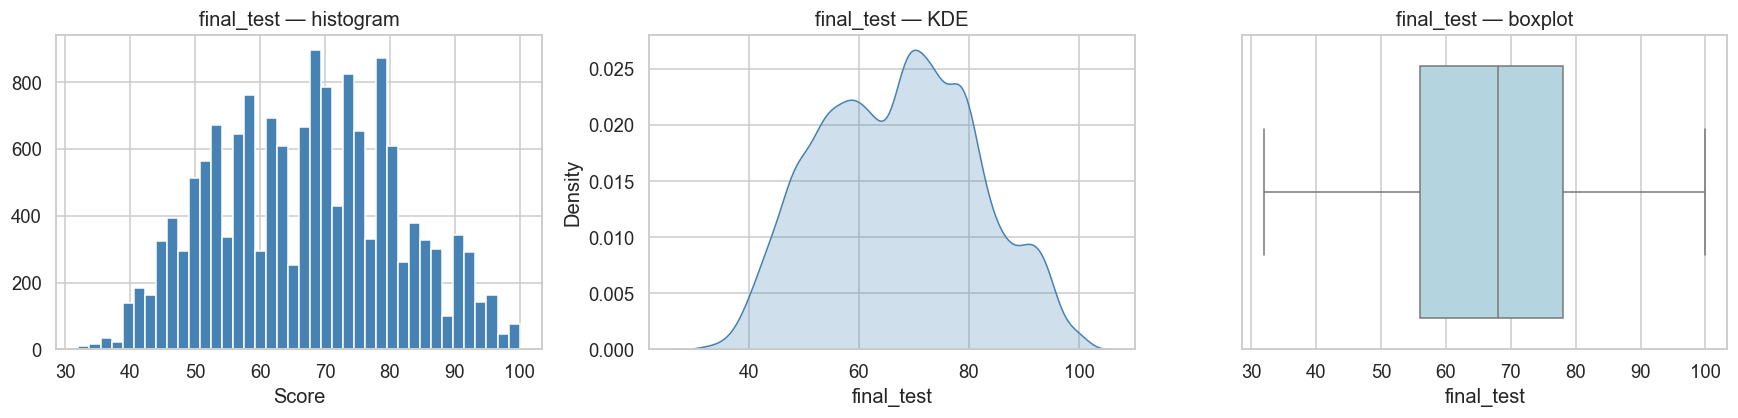

In [128]:
t = df["final_test"]

print(t.describe().round(2))
print(f"\nMissing : {t.isna().sum():,} ({100 * t.isna().mean():.1f}% of rows)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

t.hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("final_test — histogram")
axes[0].set_xlabel("Score")

sns.kdeplot(t, ax=axes[1], fill=True, color="steelblue")
axes[1].set_title("final_test — KDE")

sns.boxplot(x=t, ax=axes[2], color="lightblue")
axes[2].set_title("final_test — boxplot")

plt.tight_layout()
plt.show()

The distribution is roughly bell-shaped, centred around 67–68, with no obvious
outliers. Standard regression metrics (MAE, RMSE, R²) should be appropriate.

## 8. Numeric features vs target

Starting with the raw numeric columns. I'll engineer `class_size` in section 9
after confirming `n_male`/`n_female` are weak individually.

In [ ]:
TARGET = "final_test"

NUM_FEATURES = [
    "number_of_siblings",
    "n_male",
    "n_female",
    "age",
    "hours_per_week",
    "attendance_rate",
]

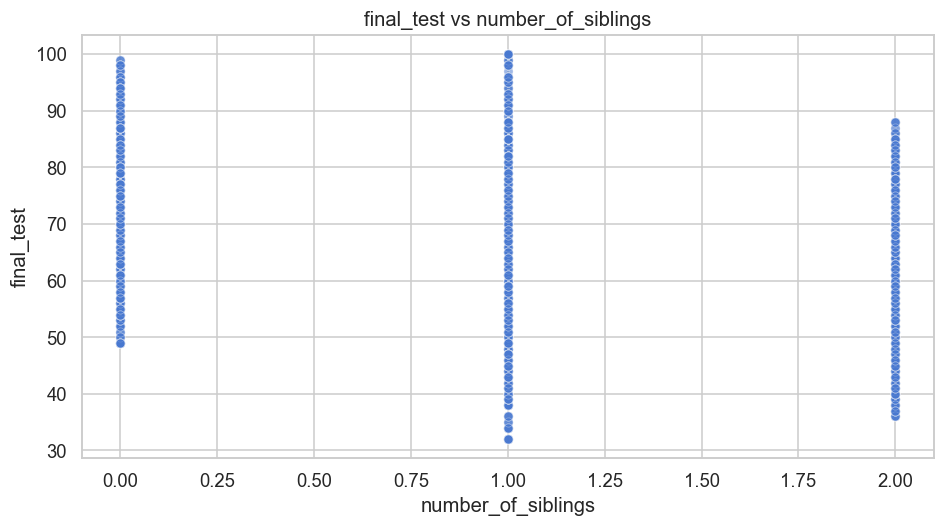

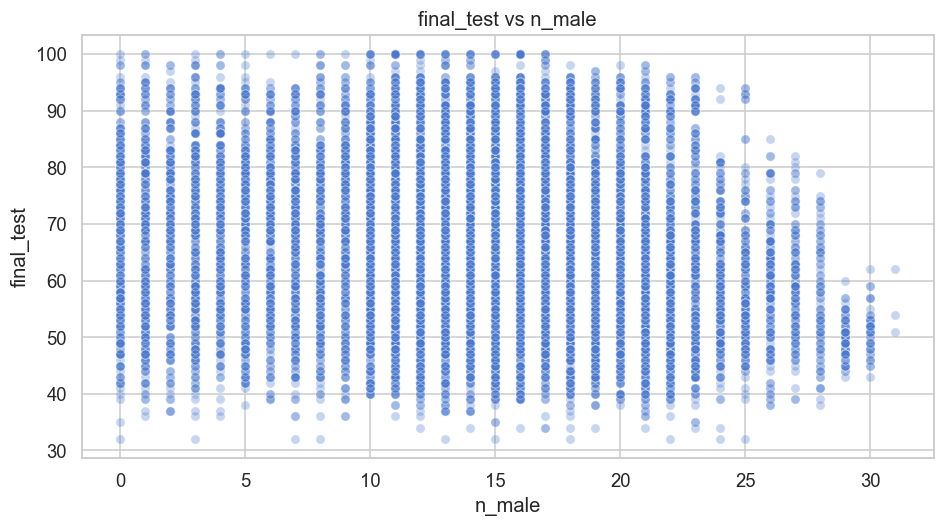

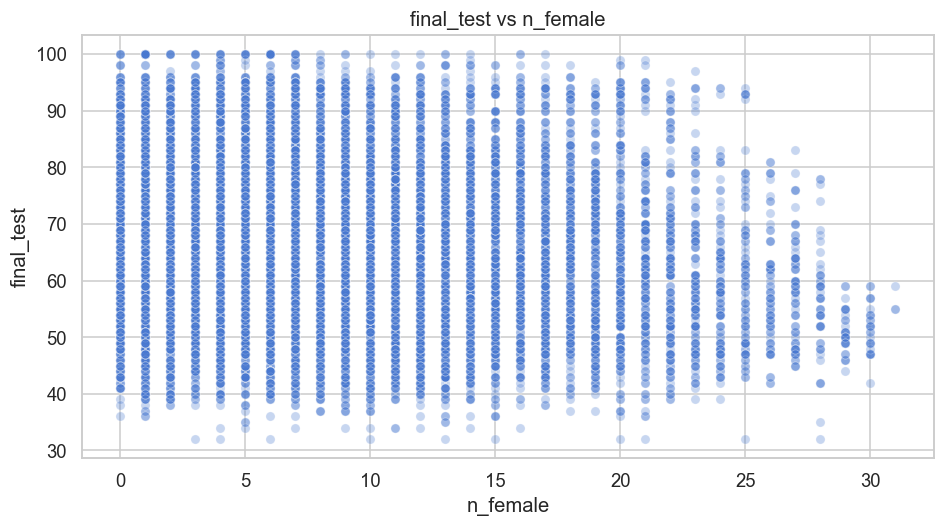

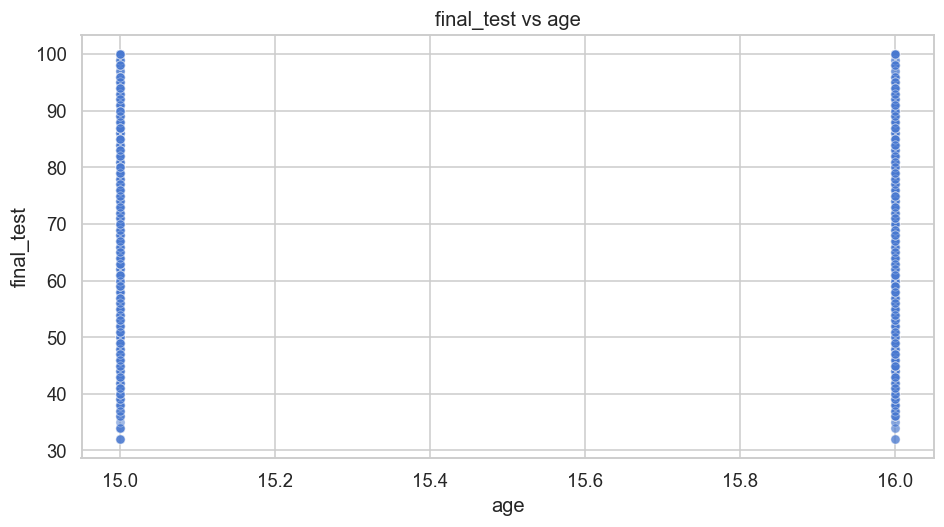

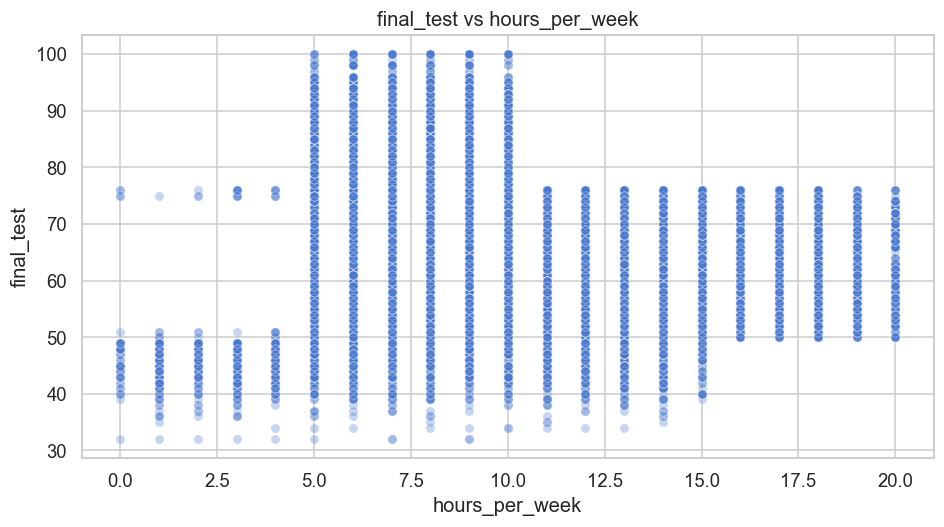

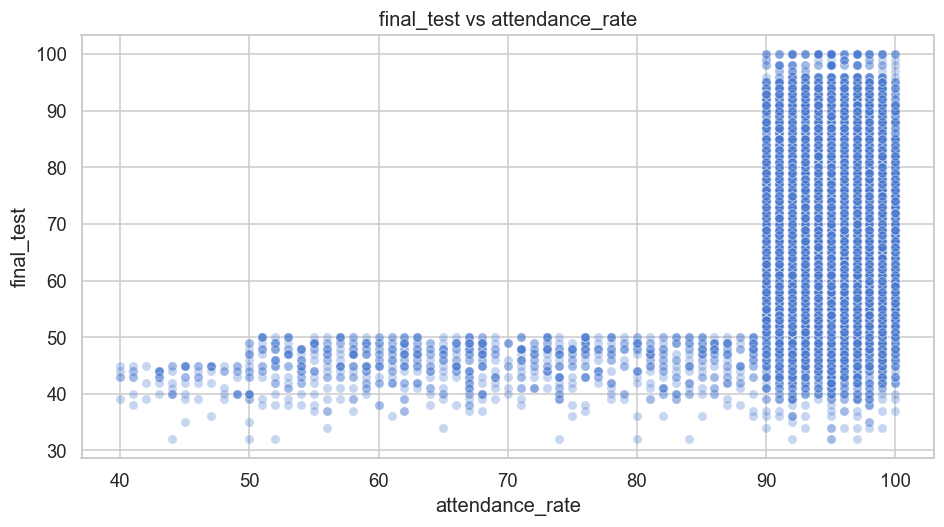

In [130]:
# Scatter plots vs target
for col in NUM_FEATURES:
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.3)
    plt.title(f"{TARGET} vs {col}")
    plt.show()

In [131]:
# Pearson and Spearman side by side
cols = [TARGET] + NUM_FEATURES
corr_pearson = df[cols].corr(method="pearson")[TARGET].sort_values(ascending=False)
corr_spearman = df[cols].corr(method="spearman")[TARGET].sort_values(ascending=False)

corr_df = pd.DataFrame({
    "pearson": corr_pearson,
    "spearman": corr_spearman,
})
corr_df

,pearson,spearman
age,0.005003,0.004075
attendance_rate,0.340202,0.160403
final_test,1.000000,1.000000
hours_per_week,-0.148254,-0.180432
n_female,-0.171978,-0.161848
n_male,-0.149152,-0.152408
number_of_siblings,-0.363767,-0.369936


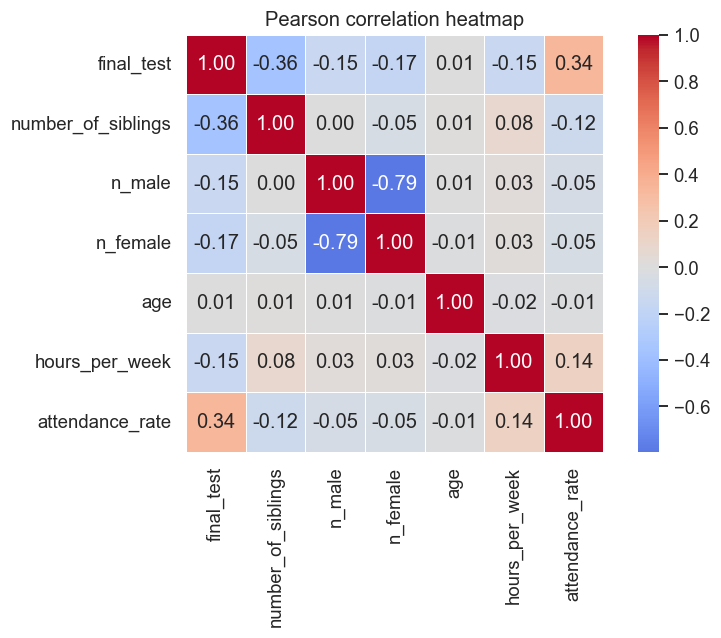

In [132]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Pearson correlation heatmap")
plt.tight_layout()
plt.show()

**Interpretation:**
- `attendance_rate` shows the strongest positive relationship with `final_test` (r ≈ 0.35) — better attendance is moderately associated with higher scores.
- `number_of_siblings` has a moderate negative correlation (r ≈ -0.36), possibly capturing socio-economic effects rather than a direct causal link.
- `hours_per_week`, `n_male`, and `n_female` show weak negative correlations (|r| ≈ 0.15–0.17). The negative sign on `hours_per_week` may reflect weaker students studying more to compensate, or noisy self-reporting.
- `age` is effectively uncorrelated (r ≈ 0.01). Since the cleaned data is almost all 15/16-year-olds, it has very little variance to begin with — I'll drop it in section 9.
- Pearson and Spearman are close, so the relationships are roughly monotonic — no obvious need for non-linear transforms before fitting.

No single numeric feature has a strong (|r| ≥ 0.5) linear correlation with the
target, so the model will need to combine several weak signals with the
categorical features.

## 9. Feature engineering

### 9.1 `class_size = n_male + n_female`

`n_male` and `n_female` look like class-composition counts. Combining them into
`class_size` is more interpretable and removes redundancy. Also dropping `age`
since it has near-zero variance after cleaning.

In [133]:
df["class_size"] = df["n_male"] + df["n_female"]
df = df.drop(columns=["n_male", "n_female", "age"])

print(df["class_size"].describe())
df["class_size"].head()

count    15405.000000
mean        22.782019
std          4.232315
min         14.000000
25%         20.000000
50%         22.000000
75%         27.000000
max         31.000000
Name: class_size, dtype: float64


0    16.0
1    23.0
2    16.0
3    22.0
4    27.0
Name: class_size, dtype: float64

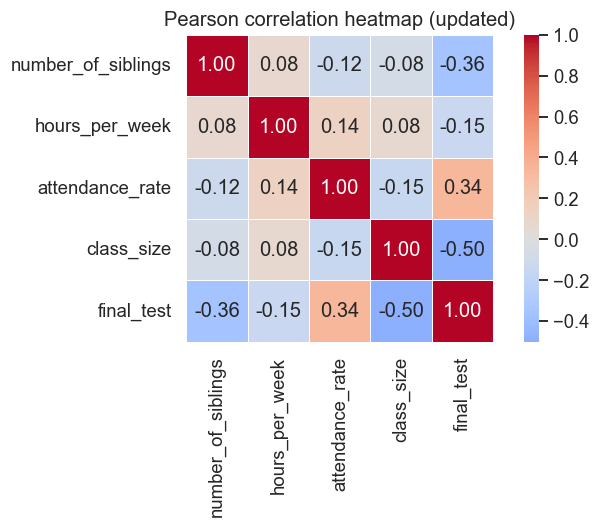

In [134]:
# Refresh numeric feature list and re-check the heatmap
NUM_FEATURES = [
    "number_of_siblings",
    "hours_per_week",
    "attendance_rate",
    "class_size",
]

plt.figure(figsize=(7, 5))
sns.heatmap(
    df[NUM_FEATURES + [TARGET]].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Pearson correlation heatmap (updated)")
plt.tight_layout()
plt.show()

`class_size` shows a weak negative correlation with `final_test`, similar in
magnitude to `n_male`/`n_female` individually — confirming the combined feature
preserves the signal.

## 10. Categorical features vs target

In [135]:
CAT_FEATURES = df.select_dtypes(include="object").columns.tolist()
print(CAT_FEATURES)

['direct_admission', 'CCA', 'learning_style', 'gender', 'tuition', 'sleep_time', 'wake_time', 'mode_of_transport']


/var/folders/st/k80_xfjd6117dgxvg81xqqdm0000gn/T/ipykernel_40052/907527167.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_FEATURES = df.select_dtypes(include="object").columns.tolist()


In [136]:
for col in CAT_FEATURES:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 40)


Column: direct_admission
direct_admission
No     10857
Yes     4548
Name: count, dtype: int64
----------------------------------------

Column: CCA
CCA
Clubs     3940
Sports    3843
None      3831
Arts      3791
Name: count, dtype: int64
----------------------------------------

Column: learning_style
learning_style
Auditory    8847
Visual      6558
Name: count, dtype: int64
----------------------------------------

Column: gender
gender
Male      7744
Female    7661
Name: count, dtype: int64
----------------------------------------

Column: tuition
tuition
Yes    8716
No     6689
Name: count, dtype: int64
----------------------------------------

Column: sleep_time
sleep_time
23:00    3021
22:00    2979
22:30    2946
21:00    2861
21:30    2781
0:00      234
23:30     180
1:00      118
0:30       88
2:00       80
1:30       70
2:30       25
3:00       22
Name: count, dtype: int64
----------------------------------------

Column: wake_time
wake_time
5:00    3141
7:00    3094
6:00    3

### 10.1 Bucket `wake_time` into Early / Medium / Late

Raw `wake_time` is a small set of time strings. Bucketing reduces cardinality
and makes the feature easier to interpret. Cutoffs:
- `5:00`, `5:30` → `Early`
- `6:00`, `6:30` → `Medium`
- `7:00` → `Late`

In [137]:
wake_time_map = {
    "5:00": "Early",
    "5:30": "Early",
    "6:00": "Medium",
    "6:30": "Medium",
    "7:00": "Late",
}

df["wake_time"] = df["wake_time"].map(wake_time_map)
print(df["wake_time"].value_counts())
print("Missing:", df["wake_time"].isna().sum())

wake_time
Early     6165
Medium    6146
Late      3094
Name: count, dtype: int64
Missing: 0


### 10.2 Bucket `sleep_time` into Early / Normal / Late

Same idea — bucketing by rough categories of when students go to bed:
- before 22:00 → `Early`
- 22:00–23:30 → `Normal`
- 00:00 onwards → `Late`

In [138]:
sleep_time_map = {
    "21:00": "Early",
    "21:30": "Early",
    "22:00": "Normal",
    "22:30": "Normal",
    "23:00": "Normal",
    "23:30": "Normal",
    "0:00":  "Late",
    "0:30":  "Late",
    "1:00":  "Late",
    "1:30":  "Late",
    "2:00":  "Late",
    "2:30":  "Late",
    "3:00":  "Late",
}

df["sleep_time"] = df["sleep_time"].map(sleep_time_map)
print(df["sleep_time"].value_counts())

sleep_time
Normal    9126
Early     5642
Late       637
Name: count, dtype: int64


### 10.3 Boxplots of `final_test` by each categorical feature

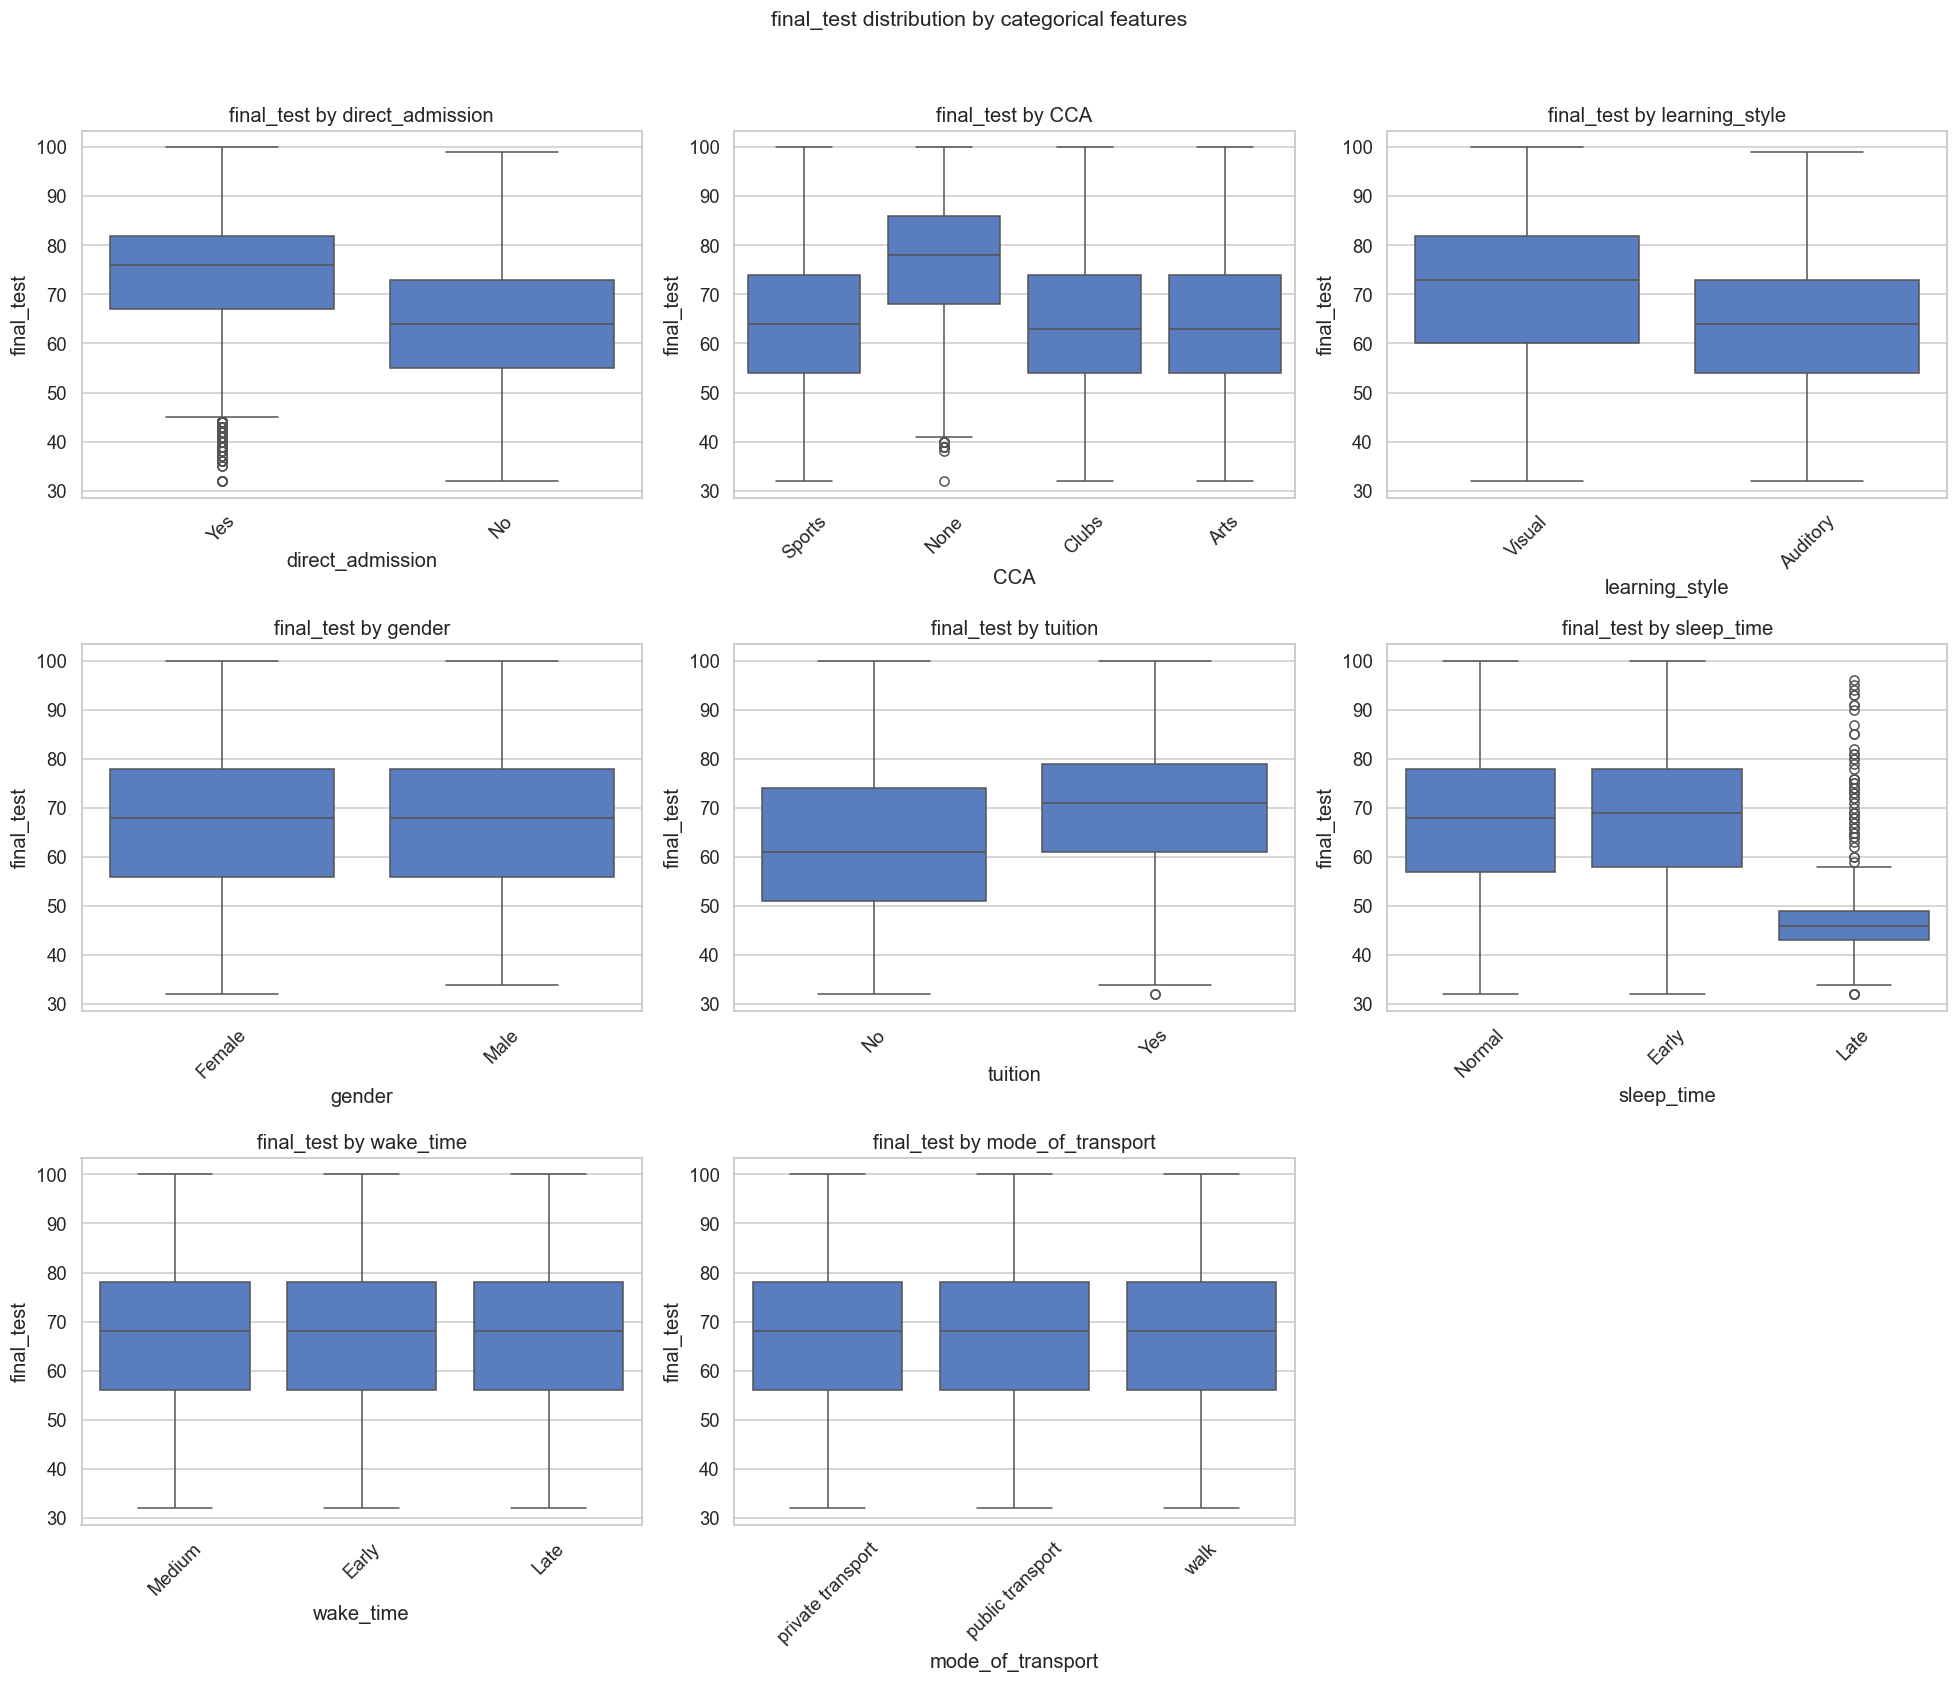

In [139]:
import math

n_cols = 3
n_rows = math.ceil(len(CAT_FEATURES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CAT_FEATURES):
    sns.boxplot(data=df, x=col, y=TARGET, ax=axes[i])
    axes[i].set_title(f"{TARGET} by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("final_test distribution by categorical features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [140]:
# Group means make small differences easier to read than boxplots
for col in CAT_FEATURES:
    print(f"\n--- {col} ---")
    print(df.groupby(col)[TARGET].mean().sort_values(ascending=False).round(2))


--- direct_admission ---
direct_admission
Yes    72.36
No     64.99
Name: final_test, dtype: float64

--- CCA ---
CCA
None      76.78
Arts      64.06
Sports    64.04
Clubs     63.85
Name: final_test, dtype: float64

--- learning_style ---
learning_style
Visual      71.59
Auditory    63.89
Name: final_test, dtype: float64

--- gender ---
gender
Male      67.33
Female    67.00
Name: final_test, dtype: float64

--- tuition ---
tuition
Yes    70.47
No     62.86
Name: final_test, dtype: float64

--- sleep_time ---
sleep_time
Early     68.41
Normal    67.75
Late      47.75
Name: final_test, dtype: float64

--- wake_time ---
wake_time
Medium    67.25
Late      67.12
Early     67.10
Name: final_test, dtype: float64

--- mode_of_transport ---
mode_of_transport
private transport    67.25
walk                 67.12
public transport     67.10
Name: final_test, dtype: float64


**Interpretation and drop decisions:**

- **Keep:** `direct_admission`, `CCA`, `learning_style`, `tuition`, `sleep_time` — all show visible differences in group means (≥ 2 points typically), suggesting useful signal.
- **Drop `gender`:** group means differ by less than ~1 point and the boxplots overlap almost entirely — no usable signal.
- **Drop `wake_time`:** even after bucketing, the three groups have nearly identical distributions.
- **Drop `mode_of_transport`:** similar overlap across categories with no clear ordering.

Dropping low-signal categoricals keeps the feature space tighter and reduces noise after one-hot encoding.

## 11. Final feature set

In [141]:
df = df.drop(columns=["gender", "wake_time", "mode_of_transport"])
CAT_FEATURES = [c for c in CAT_FEATURES if c not in {"gender", "wake_time", "mode_of_transport"}]

print("Numeric features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)
print("Target:", TARGET)
print()
print("Final shape:", df.shape)
df.columns.tolist()

Numeric features: ['number_of_siblings', 'hours_per_week', 'attendance_rate', 'class_size']
Categorical features: ['direct_admission', 'CCA', 'learning_style', 'tuition', 'sleep_time']
Target: final_test

Final shape: (15405, 11)


['number_of_siblings',
 'direct_admission',
 'CCA',
 'learning_style',
 'tuition',
 'final_test',
 'hours_per_week',
 'attendance_rate',
 'sleep_time',
 'attendance_rate_was_nan',
 'class_size']

## 12. Summary of decisions

### 12.1 Problem and target

- Prediction task: supervised **regression** to predict students’ `final_test` score from demographic, study‑habit, and school context features.
- Target distribution: `final_test` ranges from about 32 to 100, with a mean around 67 and a standard deviation around 14. Typical scores fall between the high‑50s and high‑70s, so an error of 5–8 points corresponds to roughly half a standard deviation.

### 12.2 Data quality fixes

- Dropped rows with missing `final_test` (about 3.1% of rows), since these cannot be used for supervised training and imputing the target would distort the regression problem.
- Fixed implausible ages:
  - Negative ages were treated as data errors, set to missing, then imputed with the median age.
  - Ages of 5 and 6 were corrected to 15 and 16, consistent with the stated secondary‑school age range and the modal age distribution.
- Handled missing `attendance_rate` (about 4.9% of rows):
  - Created a binary `attendance_rate_was_nan` flag so the model can still use the “missingness” signal.
  - Imputed missing `attendance_rate` with the median to preserve all rows.
- Removed identifier‑type columns:
  - Dropped `index` and `student_id` as pure row identifiers with no predictive meaning.
  - Dropped `bag_color` as a high‑cardinality nominal attribute with no plausible causal link to exam scores and poor signal‑to‑noise.
- Reduced low‑signal or hard‑to‑use columns:
  - Dropped `gender`, `wake_time`, and `mode_of_transport` after EDA showed weak relationships with `final_test` relative to other features and a risk of adding noise or unnecessary modelling complexity.

### 12.3 Feature set and leakage check

- Final feature set focuses on:
  - Demographics and context: `number_of_siblings`, `age`, `direct_admission`, `CCA`, `learning_style`, `tuition`.
  - Study behaviour: `hours_per_week`, `attendance_rate`, and the engineered indicator `attendance_rate_was_nan`.
  - Class‑level composition: `n_male`, `n_female`.
- Data leakage check:
  - A feature is considered leakage if it would not be available at the moment a prediction is made in the real world (for example, a variable that directly encodes the final exam result or something observed only after the exam).
  - In this dataset, none of the retained features are direct functions of `final_test` or post‑outcome information. All kept variables describe student characteristics, study habits, or class composition that would reasonably be known before the final exam. Columns dropped for other reasons (IDs, bag color) were removed for signal/noise rather than leakage concerns.

### 12.4 Implications for modelling

- The cleaned dataset has a well‑behaved continuous target and a mix of numeric and categorical predictors after removing obvious data errors and low‑value columns.
- These decisions will be implemented as reusable functions in the `src/` preprocessing pipeline so that the modelling code can rely on a consistent, cleaned feature set.